# New Section

In [ ]:
# 1. INSTALLATION
!pip install chembl_webresource_client rdkit tqdm openpyxl -q

import pandas as pd
from chembl_webresource_client.new_client import new_client
from rdkit import Chem
from rdkit.Chem import AllChem, PandasTools
from tqdm import tqdm

print("--- Requesting Large Dataset (EGFR) ---")

try:
    # 2. TARGET EGFR (CHEMBL203)
    activities = new_client.activity.filter(target_chembl_id='CHEMBL203').filter(standard_type="IC50")

    # 3. BATCH DOWNLOAD (Pulling 2,000+ compounds)
    data = []
    # We use a loop to fetch a significant number of compounds
    # Increase the 2000 to 5000 if you need even more
    limit = 2000

    for act in tqdm(activities, total=limit, desc="Downloading Molecules"):
        data.append(act)
        if len(data) >= limit:
            break

    df = pd.DataFrame(data)

    if not df.empty:
        # 4. CLEAN AND CALCULATE
        df = df.dropna(subset=['canonical_smiles', 'standard_value'])

        print(f"Calculating properties for {len(df)} compounds...")
        tqdm.pandas()

        def get_props(smiles):
            mol = Chem.MolFromSmiles(smiles)
            if mol:
                return pd.Series({
                    'Mol_Weight': round(Chem.rdMolDescriptors.CalcExactMolWt(mol), 2),
                    'Formula': Chem.rdMolDescriptors.CalcMolFormula(mol)
                })
            return pd.Series({'Mol_Weight': None, 'Formula': None})

        props = df['canonical_smiles'].progress_apply(get_props)
        final_df = pd.concat([df, props], axis=1)

        # 5. EXPORT LARGE FILES
        # Select important columns to keep the file size manageable
        final_cols = ['molecule_chembl_id', 'canonical_smiles', 'standard_value', 'standard_units', 'Mol_Weight', 'Formula']

        # Save Excel
        final_df[final_cols].to_excel("EGFR_Large_Summary.xlsx", index=False)

        # Save SDF (This creates the structural library)
        PandasTools.AddMoleculeColumnToFrame(final_df, 'canonical_smiles', 'Molecule')
        PandasTools.WriteSDF(final_df, 'EGFR_Large_Library.sdf', molColName='Molecule', idName='molecule_chembl_id', properties=list(final_df.columns))

        print(f"\n✅ SUCCESS! Generated files with {len(final_df)} compounds.")
        print("Check the files tab for 'EGFR_Large_Summary.xlsx' and 'EGFR_Large_Library.sdf'")
    else:
        print("❌ Server error: The database returned an empty list. Please try again in 10 minutes.")

except Exception as e:
    print(f"❌ Connection Error: {e}")
    print("The ChEMBL server is still experiencing issues. This is a temporary external problem.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.4 MB/s eta 0:00:00
--- Requesting Large Dataset (EGFR) ---


Calculating properties for 1918 compounds...


100%|██████████| 1918/1918 [00:00<00:00, 2093.09it/s]



✅ SUCCESS! Generated files with 1918 compounds.
Check the files tab for 'EGFR_Large_Summary.xlsx' and 'EGFR_Large_Library.sdf'


In [ ]:
import os
import pandas as pd
from rdkit import Chem
from tqdm import tqdm

# 1. Automatically find your files
all_files = os.listdir('/content')
# Changed to look for .xlsx file
csv_path = next((f for f in all_files if 'Summary' in f and f.endswith('.xlsx')), None)
sdf_path = next((f for f in all_files if 'Library' in f and f.endswith('.sdf')), None)

if not csv_path or not sdf_path:
    print("❌ Still can't find files! Please make sure they appear in the folder icon on the left.")
    print(f"Current files found: {all_files}")
else:
    print(f"✅ Found Excel: {csv_path}")
    print(f"✅ Found SDF: {sdf_path}")

    # 2. Run Sanity Check
    # Changed to read Excel file
    df = pd.read_excel(csv_path)
    print(f"\nTotal compounds in Excel: {len(df)}")

    # Check IC50 values
    bad_ic50 = len(df[df['standard_value'] <= 0])
    print(f"Compounds with invalid IC50 (<=0): {bad_ic50}")

    # Check Structure Validity
    print("Verifying structures...")
    df['Valid'] = df['canonical_smiles'].apply(lambda x: Chem.MolFromSmiles(x) is not None)
    invalid = len(df[df['Valid'] == False])
    print(f"Compounds with invalid structures: {invalid}")

    if bad_ic50 == 0 and invalid == 0:
        print("\n🌟 RESULT: DATA IS SANE!")
    else:
        print("\n⚠️ RESULT: DATA NEEDS CLEANING.")

✅ Found Excel: EGFR_Large_Summary.xlsx
✅ Found SDF: EGFR_Large_Library.sdf

Total compounds in Excel: 1918
Compounds with invalid IC50 (<=0): 0
Verifying structures...
Compounds with invalid structures: 0

🌟 RESULT: DATA IS SANE!


In [ ]:
import pandas as pd

# Load the final clean file
df_final = pd.read_csv(/content/EGFR_Cleaned_Dataset.csv)

# Show the first 5 rows
print("Preview of Cleaned Dataset:")
display(df_final[['molecule_chembl_id', 'standard_value', 'pIC50', 'standard_smiles']].head())

# Check if any ID still has duplicates
duplicates_left = df_final['molecule_chembl_id'].duplicated().sum()
print(f"\nRemaining duplicate IDs: {duplicates_left}")

SyntaxError: invalid syntax (3738711049.py, line 4)

In [ ]:
import pandas as pd
import os

# 1. Automatically find the cleaned file in your folder
all_files = os.listdir('/content')
# Look for the file we just created
target_file = next((f for f in all_files if 'Cleaned' in f and f.endswith('.csv')), None)

if target_file:
    print(f"✅ Found file: {target_file}")
    # 2. Read the file with quotes handled automatically
    df_final = pd.read_csv(f'/content/{target_file}')

    # 3. Quick Inspection
    print(f"Total Unique Molecules: {len(df_final)}")
    display(df_final[['molecule_chembl_id', 'pIC50', 'standard_value']].head())
else:
    print("❌ Could not find the cleaned file. Did you run the cleaning script in the previous cell?")

✅ Found file: EGFR_Cleaned_Dataset.csv
Total Unique Molecules: 1402


,molecule_chembl_id,pIC50,standard_value
0,CHEMBL53711,11.221849,0.006
1,CHEMBL35820,11.221849,0.006
2,CHEMBL53753,11.096910,0.008
3,CHEMBL66031,11.096910,0.008
4,CHEMBL29197,10.602060,0.025


In [ ]:
import pandas as pd

# Load the final clean file
df_final = pd.read_csv('/content/EGFR_Cleaned_Dataset.csv')

# Show the first 5 rows
print("Preview of Cleaned Dataset:")
display(df_final[['molecule_chembl_id', 'standard_value', 'pIC50', 'standard_smiles']].head())

# Check if any ID still has duplicates
duplicates_left = df_final['molecule_chembl_id'].duplicated().sum()
print(f"\nRemaining duplicate IDs: {duplicates_left}")

Preview of Cleaned Dataset:


KeyError: "['standard_smiles'] not in index"

In [ ]:
import pandas as pd
import os

# 1. Load the file
file_path = '/content/EGFR_Cleaned_Dataset.csv'
df_final = pd.read_csv(file_path)

# 2. Automatically find the SMILES column name
# It looks for names like 'standard_smiles', 'clean_smiles', or 'canonical_smiles'
potential_names = ['standard_smiles', 'clean_smiles', 'canonical_smiles']
smiles_col = next((col for col in potential_names if col in df_final.columns), None)

if smiles_col:
    print(f"✅ Found SMILES in column: '{smiles_col}'")
    # 3. Rename it to 'standard_smiles' so your other code works
    df_final = df_final.rename(columns={smiles_col: 'standard_smiles'})

    # 4. Success check
    print(f"Total Unique Molecules: {len(df_final)}")
    display(df_final[['molecule_chembl_id', 'pIC50', 'standard_smiles']].head())
else:
    print("❌ Error: Could not find any SMILES column. Here are the columns available:")
    print(df_final.columns.tolist())

✅ Found SMILES in column: 'canonical_smiles'
Total Unique Molecules: 1402


,molecule_chembl_id,pIC50,standard_smiles
0,CHEMBL53711,11.221849,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1
1,CHEMBL35820,11.221849,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC
2,CHEMBL53753,11.096910,CNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1
3,CHEMBL66031,11.096910,Brc1cccc(Nc2ncnc3cc4[nH]cnc4cc23)c1
4,CHEMBL29197,10.602060,COc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OC


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load your cleaned data with properties
df = pd.read_csv('EGFR_Cleaned_with_Properties.csv')

# 2. Setup the visualization style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

# --- PLOT 1: Correlation Heatmap ---
plt.subplot(1, 2, 1)
# Selecting the scientific properties for correlation
cols_to_corr = ['pIC50', 'MW', 'LogP', 'HBD', 'HBA']
corr_matrix = df[cols_to_corr].corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title('Property Correlation Heatmap\n(How properties relate to Potency)', fontsize=14)

# --- PLOT 2: Chemical Space (MW vs LogP) ---
plt.subplot(1, 2, 2)
# We color the dots by pIC50 (Potency)
scatter = plt.scatter(df['MW'], df['LogP'], c=df['pIC50'], cmap='viridis', alpha=0.5, s=20)
plt.colorbar(scatter, label='pIC50 (Higher is More Potent)')

# Add Lipinski Rule of Five "Danger Zones"
plt.axhline(5, color='red', linestyle='--', alpha=0.7, label='LogP Limit (5)')
plt.axvline(500, color='darkred', linestyle='--', alpha=0.7, label='MW Limit (500 Da)')

plt.title('EGFR Chemical Space\n(Molecular Weight vs Lipophilicity)', fontsize=14)
plt.xlabel('Molecular Weight (Da)')
plt.ylabel('LogP (Octanol-Water Partition)')
plt.legend()

plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'EGFR_Cleaned_with_Properties.csv'

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Descriptors

# 1. Load the last successful file
try:
    df = pd.read_csv('EGFR_Cleaned_Final.csv')
    print("✅ Found 'EGFR_Cleaned_Final.csv'. Calculating properties...")
except FileNotFoundError:
    print("❌ Critical Error: Please run your 'Clean all duplicates' code again first!")
    raise

# 2. Calculate Lipinski Properties (The missing step)
def get_properties(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if not mol: return [None]*4
    return [Descriptors.MolWt(mol), Descriptors.MolLogP(mol),
            Descriptors.NumHDonors(mol), Descriptors.NumHAcceptors(mol)]

# Apply calculations to create the missing columns
df[['MW', 'LogP', 'HBD', 'HBA']] = df['standard_smiles'].apply(lambda x: pd.Series(get_properties(x)))
df.to_csv('EGFR_Cleaned_with_Properties.csv', index=False)

# 3. GENERATE VISUALIZATIONS
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- PLOT 1: Correlation Heatmap ---
cols_to_corr = ['pIC50', 'MW', 'LogP', 'HBD', 'HBA']
corr_matrix = df[cols_to_corr].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=ax1)
ax1.set_title('Property Correlation: What drives EGFR Potency?', fontsize=14)

# --- PLOT 2: Chemical Space (MW vs LogP) ---
scatter = ax2.scatter(df['MW'], df['LogP'], c=df['pIC50'], cmap='plasma', alpha=0.6, s=25)
fig.colorbar(scatter, ax=ax2, label='pIC50 (Potency)')

# Add Lipinski Danger Zones
ax2.axhline(5, color='red', linestyle='--', alpha=0.6, label='LogP Limit')
ax2.axvline(500, color='darkred', linestyle='--', alpha=0.6, label='MW Limit')

ax2.set_title('EGFR Chemical Space Map', fontsize=14)
ax2.set_xlabel('Molecular Weight (Da)')
ax2.set_ylabel('LogP (Lipophilicity)')
ax2.legend()

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'rdkit'

In [ ]:
# 1. Install RDKit if it's missing
try:
    from rdkit import Chem
    print("✅ RDKit is already installed.")
except ImportError:
    print("⏳ Installing RDKit (this takes about 30 seconds)...")
    !pip install rdkit -q
    from rdkit import Chem
    from rdkit.Chem import Descriptors
    print("✅ RDKit installed successfully!")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Load and Calculate Properties
df = pd.read_csv('EGFR_Cleaned_Final.csv')

def get_properties(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if not mol: return [None]*4
    return [Descriptors.MolWt(mol), Descriptors.MolLogP(mol),
            Descriptors.NumHDonors(mol), Descriptors.NumHAcceptors(mol)]

print("Calculating Molecular Properties...")
df[['MW', 'LogP', 'HBD', 'HBA']] = df['standard_smiles'].apply(lambda x: pd.Series(get_properties(x)))

# 3. Create the Heatmaps
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- PLOT 1: Correlation Heatmap ---
cols_to_corr = ['pIC50', 'MW', 'LogP', 'HBD', 'HBA']
corr_matrix = df[cols_to_corr].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=ax1)
ax1.set_title('Property Correlation: What drives EGFR Potency?', fontsize=14)

# --- PLOT 2: Chemical Space (MW vs LogP) ---
scatter = ax2.scatter(df['MW'], df['LogP'], c=df['pIC50'], cmap='plasma', alpha=0.6, s=25)
fig.colorbar(scatter, ax=ax2, label='pIC50 (Potency)')

# Add Lipinski Danger Zones
ax2.axhline(5, color='red', linestyle='--', alpha=0.6, label='LogP Limit')
ax2.axvline(500, color='darkred', linestyle='--', alpha=0.6, label='MW Limit')

ax2.set_title('EGFR Chemical Space Map', fontsize=14)
ax2.set_xlabel('Molecular Weight (Da)')
ax2.set_ylabel('LogP (Lipophilicity)')
ax2.legend()

plt.tight_layout()
plt.show()

⏳ Installing RDKit (this takes about 30 seconds)...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 41.6 MB/s eta 0:00:00
✅ RDKit installed successfully!


FileNotFoundError: [Errno 2] No such file or directory: 'EGFR_Cleaned_Final.csv'

✅ Found file: EGFR_Cleaned_Dataset.csv. Processing...
📊 Calculating Molecular Properties (MW, LogP)...


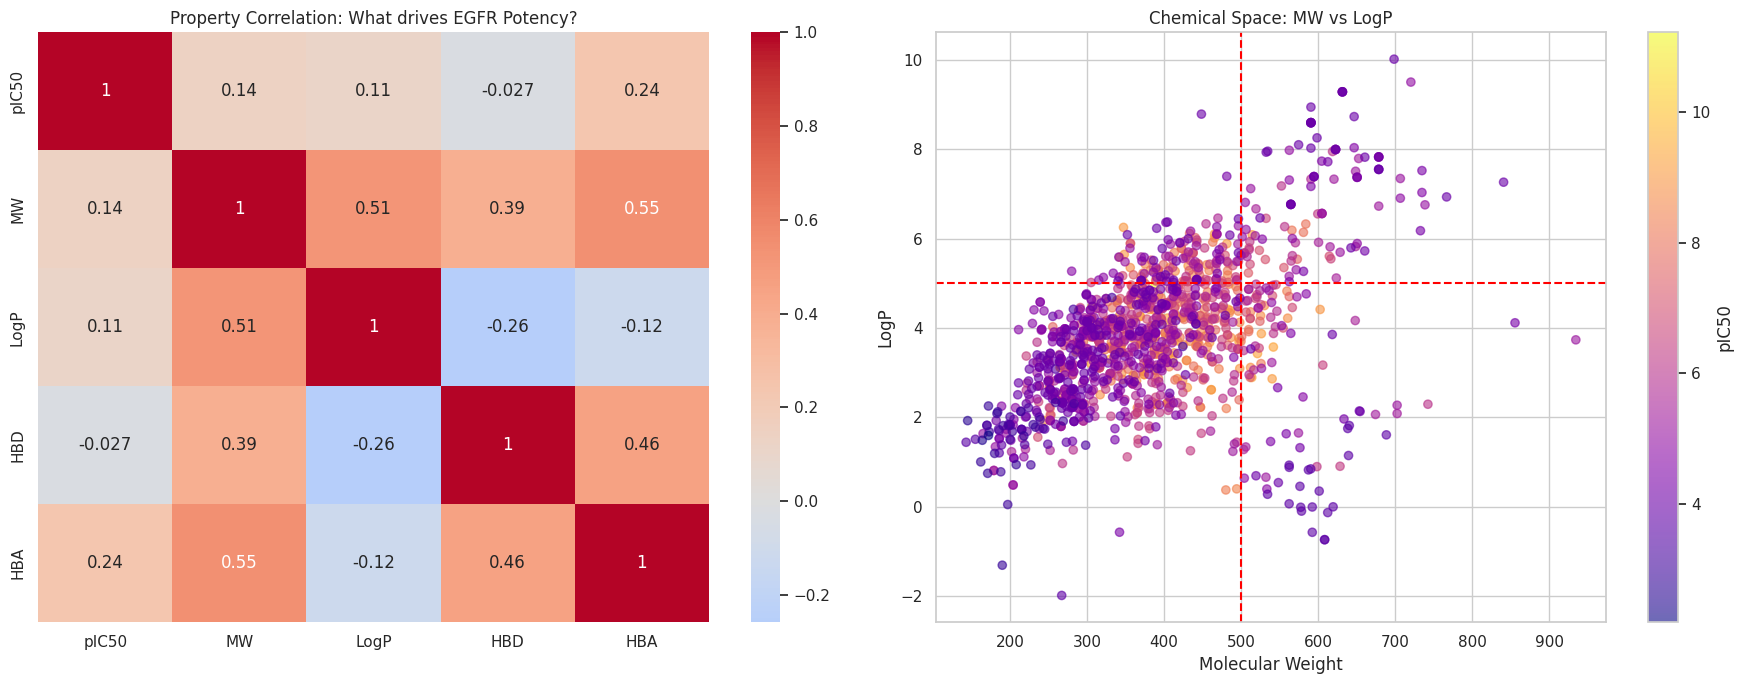

💾 Saved as 'EGFR_Cleaned_with_Properties.csv'


In [ ]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Install RDKit if missing
try:
    from rdkit import Chem
    from rdkit.Chem import Descriptors
except ImportError:
    !pip install rdkit -q
    from rdkit import Chem
    from rdkit.Chem import Descriptors

# 2. Find ANY available EGFR CSV file in your folder
all_files = os.listdir('/content')
csv_path = next((f for f in all_files if 'EGFR' in f and f.endswith('.csv')), None)

if not csv_path:
    print("❌ No EGFR files found! Please upload your 'EGFR_Large_Summary.xlsx - Sheet1.csv' to the left sidebar again.")
else:
    print(f"✅ Found file: {csv_path}. Processing...")
    df = pd.read_csv(f'/content/{csv_path}')

    # 3. Quick Clean (Deduplicate & Log Transform)
    # This ensures the data is ready even if it wasn't cleaned before
    if 'canonical_smiles' in df.columns:
        df = df.dropna(subset=['canonical_smiles', 'standard_value'])
        df = df[df['standard_value'] > 0]
        # Keep the most potent version of duplicates
        df = df.sort_values('standard_value').drop_duplicates('canonical_smiles')
        df['pIC50'] = 9 - np.log10(df['standard_value'])

        # 4. Calculate Properties for the Heatmap
        def get_props(smiles):
            mol = Chem.MolFromSmiles(smiles)
            if not mol: return [None]*4
            return [Descriptors.MolWt(mol), Descriptors.MolLogP(mol),
                    Descriptors.NumHDonors(mol), Descriptors.NumHAcceptors(mol)]

        print("📊 Calculating Molecular Properties (MW, LogP)...")
        df[['MW', 'LogP', 'HBD', 'HBA']] = df['canonical_smiles'].apply(lambda x: pd.Series(get_props(x)))

        # 5. GENERATE THE VISUALS
        sns.set_theme(style="whitegrid")
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

        # Heatmap
        cols = ['pIC50', 'MW', 'LogP', 'HBD', 'HBA']
        sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', center=0, ax=ax1)
        ax1.set_title('Property Correlation: What drives EGFR Potency?')

        # Chemical Space
        scatter = ax2.scatter(df['MW'], df['LogP'], c=df['pIC50'], cmap='plasma', alpha=0.6)
        plt.colorbar(scatter, ax=ax2, label='pIC50')
        ax2.axhline(5, color='red', linestyle='--')
        ax2.axvline(500, color='red', linestyle='--')
        ax2.set_title('Chemical Space: MW vs LogP')
        ax2.set_xlabel('Molecular Weight')
        ax2.set_ylabel('LogP')

        plt.tight_layout()
        plt.show()

        # Save so you don't lose it again!
        df.to_csv('EGFR_Cleaned_with_Properties.csv', index=False)
        print("💾 Saved as 'EGFR_Cleaned_with_Properties.csv'")

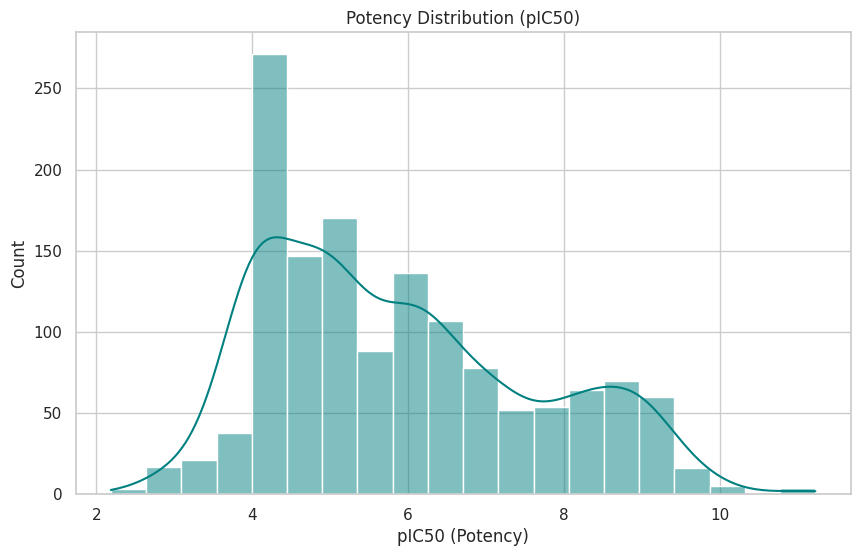

Skewness score: 0.56


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned file
df = pd.read_csv('EGFR_Cleaned_with_Properties.csv')

plt.figure(figsize=(10, 6))
sns.histplot(df['pIC50'], kde=True, color='teal')
plt.title('Potency Distribution (pIC50)')
plt.xlabel('pIC50 (Potency)')
plt.ylabel('Count')
plt.show()

# Calculate Skewness (0 is perfect, >1 is highly skewed)
print(f"Skewness score: {df['pIC50'].skew():.2f}")

In [ ]:
# 1. Install RDKit in Colab (if not already present)
!pip install rdkit

import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem
from rdkit.ML.Descriptors import MoleculeDescriptors

# 2. Upload your file manually using the file sidebar on the left,
#    or ensure 'EGFR_Cleaned_Final.csv' is in your content folder
df = pd.read_csv('EGFR_Cleaned_Final.csv')

# 3. Define the list of descriptors you want
# Using a wide range of common 2D descriptors
desc_names = [n[0] for n in Descriptors._descList]
calc = MoleculeDescriptors.MolecularDescriptorCalculator(desc_names)

# 4. Define a function to calculate descriptors for each SMILES
def calculate_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return list(calc.CalcDescriptors(mol))
    else:
        # Return a list of None if the SMILES is invalid
        return [None] * len(desc_names)

# 5. Apply the calculation to your 'canonical_smiles' column
# This may take a minute depending on the size of your dataset
print("Calculating descriptors... this might take a moment.")
df_descriptors = df['canonical_smiles'].apply(calculate_descriptors).apply(pd.Series)
df_descriptors.columns = desc_names

# 6. Merge the descriptors back with your original data
df_final = pd.concat([df, df_descriptors], axis=1)

# 7. Save the result
df_final.to_csv('EGFR_With_Descriptors_Final.csv', index=False)
print("Success! File saved as 'EGFR_With_Descriptors_Final.csv'")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 11.1 MB/s eta 0:00:00


FileNotFoundError: [Errno 2] No such file or directory: 'EGFR_Cleaned_Final.csv'

In [ ]:
# 1. Install RDKit in Colab (if not already present)
!pip install rdkit

import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem
from rdkit.ML.Descriptors import MoleculeDescriptors

# 2. Upload your file manually using the file sidebar on the left,
#    or ensure 'EGFR_Cleaned_Final.csv' is in your content folder
df = pd.read_csv(/content/EGFR_Cleaned_Final.csv)

# 3. Define the list of descriptors you want
# Using a wide range of common 2D descriptors
desc_names = [n[0] for n in Descriptors._descList]
calc = MoleculeDescriptors.MolecularDescriptorCalculator(desc_names)

# 4. Define a function to calculate descriptors for each SMILES
def calculate_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return list(calc.CalcDescriptors(mol))
    else:
        # Return a list of None if the SMILES is invalid
        return [None] * len(desc_names)

# 5. Apply the calculation to your 'canonical_smiles' column
# This may take a minute depending on the size of your dataset
print("Calculating descriptors... this might take a moment.")
df_descriptors = df['canonical_smiles'].apply(calculate_descriptors).apply(pd.Series)
df_descriptors.columns = desc_names

# 6. Merge the descriptors back with your original data
df_final = pd.concat([df, df_descriptors], axis=1)

# 7. Save the result
df_final.to_csv('EGFR_With_Descriptors_Final.csv', index=False)
print("Success! File saved as 'EGFR_With_Descriptors_Final.csv'")

SyntaxError: invalid syntax (2579215190.py, line 11)

In [ ]:
# 1. Install RDKit in Colab (if not already present)
!pip install rdkit

import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem
from rdkit.ML.Descriptors import MoleculeDescriptors

# 2. Upload your file manually using the file sidebar on the left,
#    or ensure 'EGFR_Cleaned_Final.csv' is in your content folder
df = pd.read_csv('/content/EGFR_Cleaned_Final.csv')

# 3. Define the list of descriptors you want
# Using a wide range of common 2D descriptors
desc_names = [n[0] for n in Descriptors._descList]
calc = MoleculeDescriptors.MolecularDescriptorCalculator(desc_names)

# 4. Define a function to calculate descriptors for each SMILES
def calculate_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return list(calc.CalcDescriptors(mol))
    else:
        # Return a list of None if the SMILES is invalid
        return [None] * len(desc_names)

# 5. Apply the calculation to your 'canonical_smiles' column
# This may take a minute depending on the size of your dataset
print("Calculating descriptors... this might take a moment.")
df_descriptors = df['canonical_smiles'].apply(calculate_descriptors).apply(pd.Series)
df_descriptors.columns = desc_names

# 6. Merge the descriptors back with your original data
df_final = pd.concat([df, df_descriptors], axis=1)

# 7. Save the result
df_final.to_csv('EGFR_With_Descriptors_Final.csv', index=False)
print("Success! File saved as 'EGFR_With_Descriptors_Final.csv'")

Calculating descriptors... this might take a moment.
Success! File saved as 'EGFR_With_Descriptors_Final.csv'


In [ ]:
print(df.isnull().sum().sum())

0


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your file
df = pd.read_csv('/content/EGFR_With_ onlyIC50_Descriptors_.csv')

# Step 1: Clean the data (Drop metadata and empty rows)
cols_to_drop = ['molecule_chembl_id', 'canonical_smiles', 'standard_value', 'standard_units', 'Formula', 'standard_smiles']
df_clean = df.drop(columns=cols_to_drop, errors='ignore').dropna()

# Step 2: Correlate descriptors with pIC50
correlation = df_clean.corr()['pIC50'].abs().sort_values(ascending=False)

# Step 3: Print the top 10 (You can copy this into your report!)
print("Top 10 Descriptors Correlated with pIC50:")
print(correlation.iloc[1:11])

# Step 4: Visualize (This plot goes in your dissertation!)
plt.figure(figsize=(10, 6))
correlation.iloc[1:11].plot(kind='bar', color='darkcyan')
plt.title('Top 10 Descriptors Correlated with pIC50')
plt.ylabel('Absolute Correlation Coefficient')
plt.show()

ValueError: could not convert string to float: 'CHEMBL554983'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data
file_path = '/content/EGFR_With_onlyIC50_Descriptors_.csv' # Double check this path!
df = pd.read_csv(file_path)

# 2. Clean the data (Drop metadata and empty rows)
cols_to_drop = ['molecule_chembl_id', 'canonical_smiles', 'standard_value',
                'standard_units', 'Formula', 'standard_smiles']
df_clean = df.drop(columns=cols_to_drop, errors='ignore')
df_clean = df_clean.apply(pd.to_numeric, errors='coerce').dropna()

# 3. Calculate correlation
correlation = df_clean.corr()['pIC50'].abs().sort_values(ascending=False)

# 4. Plot the graph
plt.figure(figsize=(10, 6))
# We plot index 1 to 11 to skip 'pIC50' itself (which has a correlation of 1.0)
correlation.iloc[1:11].plot(kind='bar', color='darkcyan')

plt.title('Top 10 Descriptors Correlated with pIC50')
plt.ylabel('Absolute Correlation Coefficient')
plt.xlabel('Chemical Descriptor')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# This command ensures the plot is displayed
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/EGFR_With_onlyIC50_Descriptors_.csv'

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load your file
df = pd.read_csv('/content/EGFR_With_ onlyIC50_Descriptors_.csv') # Make sure this is your CSV path

# 2. Drop the text columns explicitly (metadata)
# We drop everything that is NOT numeric
cols_to_drop = ['molecule_chembl_id', 'canonical_smiles', 'standard_value',
                'standard_units', 'Formula', 'standard_smiles']
df_clean = df.drop(columns=cols_to_drop, errors='ignore')

# 3. EXTRA STEP: Ensure everything else is numeric
# This line forces everything to be a number and ignores errors
df_clean = df_clean.apply(pd.to_numeric, errors='coerce')

# 4. Remove any rows that have missing values (which might have turned into NaN)
df_clean = df_clean.dropna()

# 5. NOW calculate the correlation
correlation = df_clean.corr()['pIC50'].abs().sort_values(ascending=False)

# 6. Display results
print("Top 10 Descriptors Correlated with pIC50:")
print(correlation.iloc[1:11])

Top 10 Descriptors Correlated with pIC50:
pIC50               NaN
MaxAbsEStateIndex   NaN
MaxEStateIndex      NaN
MinAbsEStateIndex   NaN
MinEStateIndex      NaN
qed                 NaN
SPS                 NaN
MolWt               NaN
HeavyAtomMolWt      NaN
ExactMolWt          NaN
Name: pIC50, dtype: float64


Top 10 Descriptors Correlated with pIC50:
PEOE_VSA3           0.587036
BCUT2D_MWHI         0.537861
fr_aniline          0.522897
EState_VSA8         0.507674
fr_Ar_N             0.499012
SlogP_VSA10         0.481566
SMR_VSA3            0.459288
fr_NH0              0.452466
FpDensityMorgan3    0.406369
fr_halogen          0.362788
Name: pIC50, dtype: float64


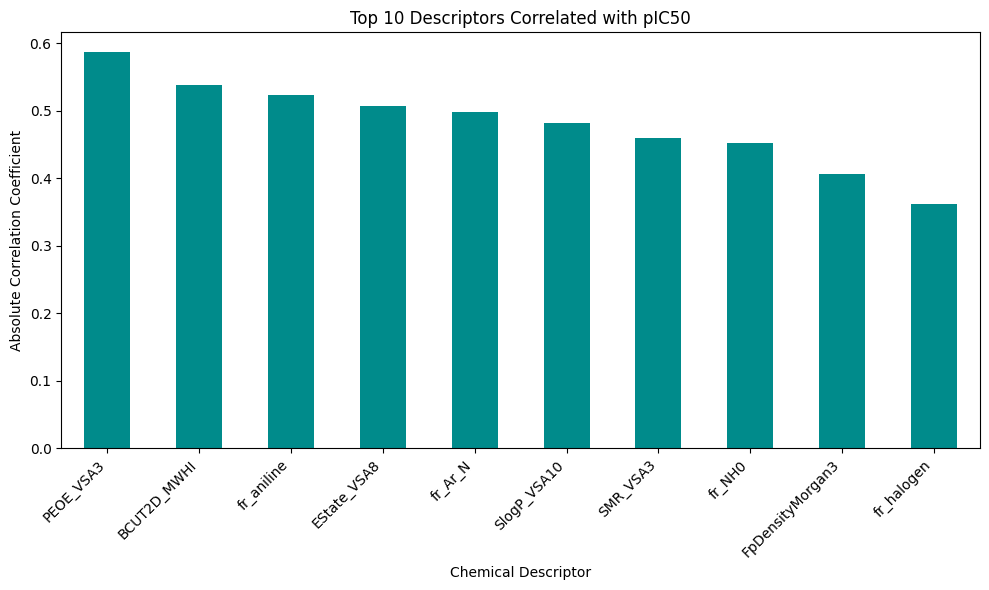

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data
file_path = '/content/EGFR_With_ onlyIC50_Descriptors_.csv'
df = pd.read_csv(file_path)

# 2. Define the columns we want to remove
# We remove all identifiers, text columns, and the problematic empty 'm' column
cols_to_drop = ['Unnamed: 0', 'molecule_chembl_id', 'canonical_smiles',
                'standard_value', 'standard_units', 'Formula', 'standard_smiles', 'm']

# Create a clean dataframe by dropping only the junk columns
df_clean = df.drop(columns=cols_to_drop, errors='ignore')

# 3. Force all remaining columns to be numeric
# We convert columns individually to protect pIC50
for col in df_clean.columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# 4. Drop rows that have NaN in pIC50 (essential!)
# We only drop rows where the target value is missing
df_clean = df_clean.dropna(subset=['pIC50'])

# 5. Fill any remaining NaNs in descriptors with 0 (prevents data loss)
df_clean = df_clean.fillna(0)

# 6. Calculate correlation
correlation = df_clean.corr()['pIC50'].abs().sort_values(ascending=False)

# 7. Print the Top 10 (excluding pIC50 itself)
print("Top 10 Descriptors Correlated with pIC50:")
print(correlation.iloc[1:11])

# 8. Visualize
plt.figure(figsize=(10, 6))
correlation.iloc[1:11].plot(kind='bar', color='darkcyan')
plt.title('Top 10 Descriptors Correlated with pIC50')
plt.ylabel('Absolute Correlation Coefficient')
plt.xlabel('Chemical Descriptor')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# 1. Load your manually cleaned file
# Change the filename if you named it differently
df = pd.read_csv('/content/EGFR_With_ onlyIC50_Descriptors_.csv')

# 2. Separate the Target (y)
y = df['pIC50']

# 3. Create the Feature Matrix (X) by dropping the ID and the Target
# We drop 'Unnamed: 0' as requested by your mentor
X = df.drop(columns=['Unnamed: 0', 'pIC50'], errors='ignore')

print("Step 2 Complete:")
print(f"Target (y) shape: {y.shape}")
print(f"Feature Matrix (X) shape: {X.shape}")
print(f"Confirming 'Unnamed: 0' is gone: {'Unnamed: 0' in X.columns}")

Step 2 Complete:
Target (y) shape: (1392,)
Feature Matrix (X) shape: (1392, 217)
Confirming 'Unnamed: 0' is gone: False


In [ ]:
import numpy as np
from sklearn.feature_selection import VarianceThreshold

# 1. Initialize the selector
# Threshold 0.01 removes features that are constant in ~99% of the samples
selector = VarianceThreshold(threshold=0.01)

# 2. Apply it to your feature matrix X
# Note: X is the dataframe from Step 2 that had the ID column removed
selector.fit(X)
X_variance_filtered = X.loc[:, selector.get_support()]

# 3. Print the results
print("Step 3 Complete:")
print(f"Original number of descriptors: {X.shape[1]}")
print(f"Descriptors remaining: {X_variance_filtered.shape[1]}")
print(f"Number of constant/near-constant descriptors removed: {X.shape[1] - X_variance_filtered.shape[1]}")

Step 3 Complete:
Original number of descriptors: 217
Descriptors remaining: 174
Number of constant/near-constant descriptors removed: 43


In [ ]:
import numpy as np

# 1. Calculate the correlation matrix
corr_matrix = X_variance_filtered.corr().abs()

# 2. Select the upper triangle of the correlation matrix
# (This prevents us from comparing a column to itself or comparing the same pair twice)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 3. Find features with correlation greater than 0.90
to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]

# 4. Drop the highly collinear features
X_final_features = X_variance_filtered.drop(columns=to_drop)

print("Step 4 Complete:")
print(f"Descriptors before collinearity filter: {X_variance_filtered.shape[1]}")
print(f"Descriptors removed due to high collinearity: {len(to_drop)}")
print(f"Descriptors remaining: {X_final_features.shape[1]}")

Step 4 Complete:
Descriptors before collinearity filter: 174
Descriptors removed due to high collinearity: 44
Descriptors remaining: 130


In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the Scaler
scaler = StandardScaler()

# 2. Fit and transform the feature matrix
# This turns your data into a NumPy array of standardized values
X_standardized_array = scaler.fit_transform(X_final_features)

# 3. Convert it back into a nice DataFrame so we keep the column names
X_standardized = pd.DataFrame(X_standardized_array, columns=X_final_features.columns)

print("Step 5 Complete:")
print(f"Final shape of X: {X_standardized.shape}")
print(f"Mean of first column (should be ~0): {X_standardized.iloc[:, 0].mean():.2f}")
print(f"Std Dev of first column (should be 1): {X_standardized.iloc[:, 0].std():.2f}")

# 4. EXPORT THE FINAL CLEANED DATA
# We combine X and y back together for your final file
final_dataset = X_standardized.copy()
final_dataset['pIC50'] = y.values

final_dataset.to_csv('EGFR_Final_Processed_Data.csv', index=False)
print("\nSuccess! Your final cleaned and standardized file 'EGFR_Final_Processed_Data.csv' is ready in the Colab folder.")

Step 5 Complete:
Final shape of X: (1392, 130)
Mean of first column (should be ~0): -0.00
Std Dev of first column (should be 1): 1.00

Success! Your final cleaned and standardized file 'EGFR_Final_Processed_Data.csv' is ready in the Colab folder.


Top 10 Descriptors and their Correlation with pIC50:
PEOE_VSA3      0.586994
BCUT2D_MWHI    0.537878
EState_VSA8    0.511033
fr_Ar_N        0.499086
SlogP_VSA10    0.481494
SMR_VSA3       0.461057
fr_NH0         0.453142
fr_halogen     0.362662
SMR_VSA6       0.343324
BCUT2D_MRHI    0.342883
Name: pIC50, dtype: float64


/tmp/ipykernel_454/1160462460.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_values.values, y=top_10_values.index, palette='RdBu_r')


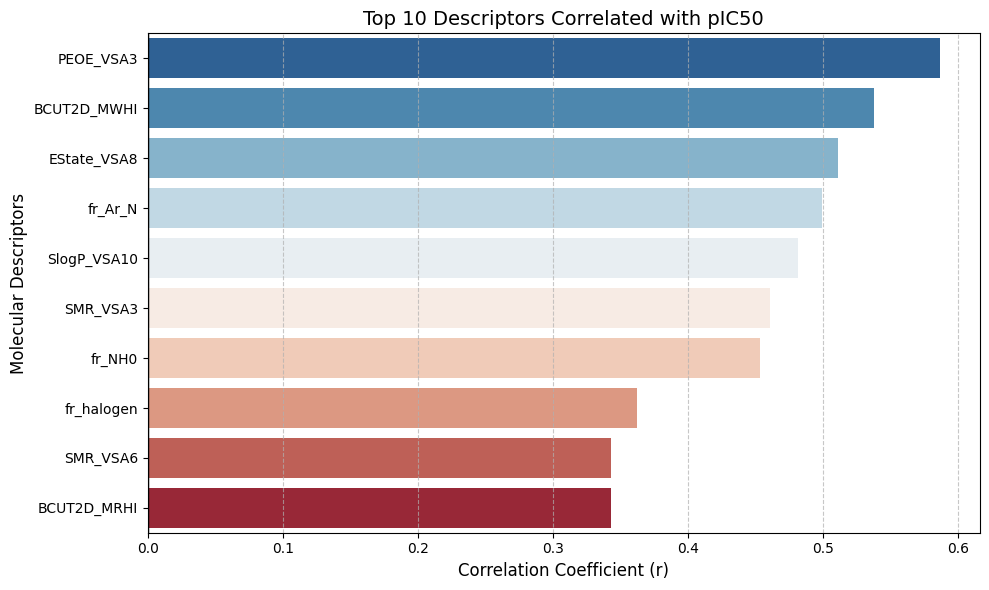

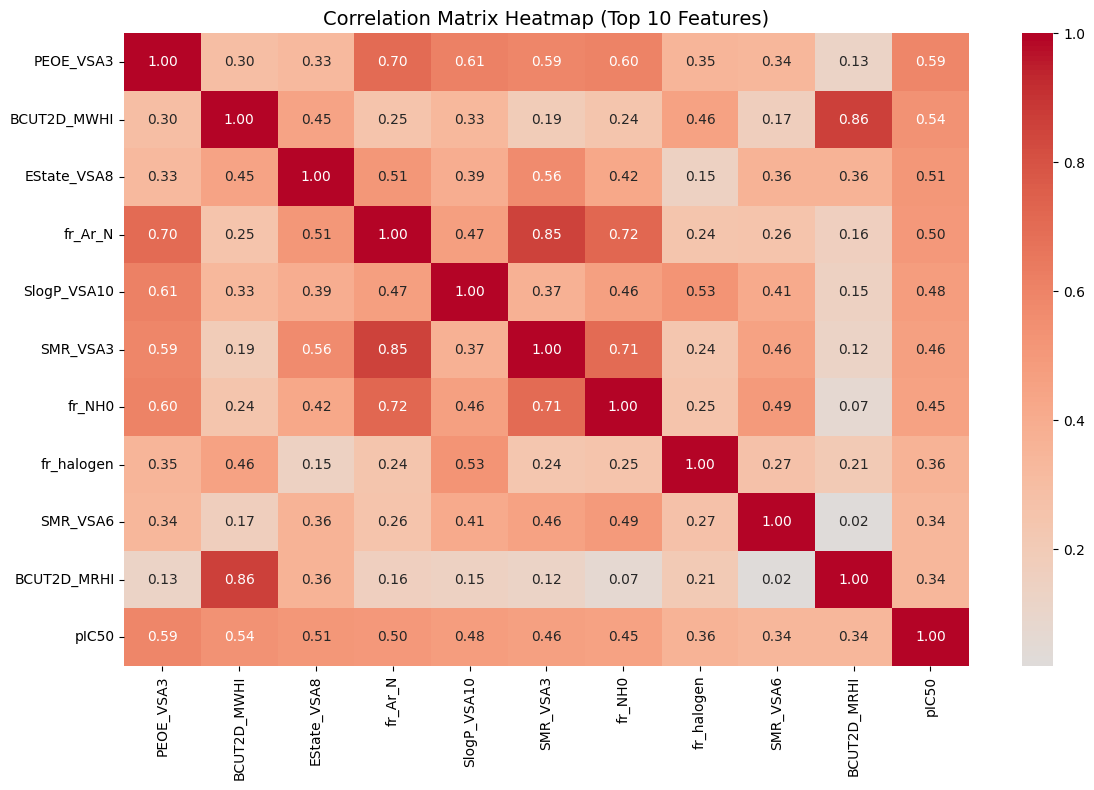

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the processed dataset
# Ensure you have uploaded 'EGFR_Final_Processed_Data.csv' to your Colab session
file_path = '/content/EGFR_Final_Processed_Data.csv'
df = pd.read_csv(file_path)

# 2. Calculate the correlation of all descriptors with pIC50
# We drop pIC50 from the series so we don't correlate it with itself
correlations = df.corr()['pIC50'].drop('pIC50')

# 3. Get the absolute correlation values and sort them to find the "strongest"
abs_correlations = correlations.abs().sort_values(ascending=False)
top_10_names = abs_correlations.head(10).index
top_10_values = correlations[top_10_names] # Keep original signs (positive/negative)

print("Top 10 Descriptors and their Correlation with pIC50:")
print(top_10_values)

# 4. Visualization: Bar Chart of Top 10
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_values.values, y=top_10_values.index, palette='RdBu_r')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.title('Top 10 Descriptors Correlated with pIC50', fontsize=14)
plt.xlabel('Correlation Coefficient (r)', fontsize=12)
plt.ylabel('Molecular Descriptors', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 5. Visualization: Correlation Heatmap
# This shows how the top 10 descriptors relate to pIC50 AND each other
top_10_list = list(top_10_names) + ['pIC50']
heatmap_data = df[top_10_list].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title('Correlation Matrix Heatmap (Top 10 Features)', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
import ipywidgets as widgets
from IPython.display import display

# Define your project steps
steps = [
    "Data Collection",
    "Data Cleaning (Missing Values)",
    "Feature Selection (Variance/Correlation)",
    "Data Standardization",
    "Model Training (Random Forest)",
    "Model Evaluation (R2/RMSE)"
]

# We are currently at Step 4 (Completed up to Standardization)
current_step = 4

progress = widgets.IntProgress(
    value=current_step,
    min=0,
    max=len(steps),
    description='Progress:',
    bar_style='success', # 'success', 'info', 'warning', 'danger' or ''
    orientation='horizontal'
)

label = widgets.Label(value=f"Current Milestone: {steps[current_step-1]}")

print(f"Project Completion: {int((current_step/len(steps))*100)}%")
display(progress, label)

Project Completion: 66%


IntProgress(value=4, bar_style='success', description='Progress:', max=6)

Label(value='Current Milestone: Data Standardization')